## Exploratory Data Analysis (EDA)

### EDA Introduction
 Exploratory Data Analysis (EDA)

The purpose of this Exploratory Data Analysis is to understand the employee dataset and identify patterns, relationships, and factors associated with employee attrition.

The analysis focuses on employee demographics, job characteristics, workload, satisfaction, compensation, career progression, and tenure.

The main objective is to answer the business question:

**What workplace, demographic, and career factors are most strongly associated with employee attrition?**

## Business Goals

### Goal 1: Reduce Employee Attrition

Identify the key factors associated with employees leaving the organisation in order to support the development of effective employee retention strategies.

### Goal 2: Improve Employee Retention in High-Risk Departments and Job Roles

Identify departments and job roles with relatively higher attrition rates so that HR can prioritise targeted retention initiatives.

# Hypotheses

The following hypotheses will be investigated using exploratory data analysis and statistical testing.

## H1: Job Role and Employee Attrition

**Alternative Hypothesis (H1):** Attrition differs significantly between job roles.

**Null Hypothesis (H0):** Attrition is independent of job role; attrition rates do not differ significantly across job roles.

---

## H2: Promotion History and Employee Attrition

**Alternative Hypothesis (H1):** Employees with limited promotion history have higher attrition.

**Null Hypothesis (H0):** Employees with limited promotion history do not have higher attrition; there is no association between promotion history and attrition.

---

## H3: Monthly Income and Employee Attrition

**Alternative Hypothesis (H1):** Lower-income employees have higher attrition rates.

**Null Hypothesis (H0):** Monthly income is not associated with attrition; lower-income employees do not have higher attrition.

## Objectives

* 
## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 


# Change working directory

 * We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [5]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\Pdhar\\OneDrive\\Documents\\Hackathon_2026_Group_1\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [6]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [7]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\Pdhar\\OneDrive\\Documents\\Hackathon_2026_Group_1'

# Section 1
## 1. Import Packages and Libraries

## Load the Dataset

In [4]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load cleaned dataset
df = pd.read_csv(r"C:\Users\Pdhar\OneDrive\Documents\Hackathon_2026_Group_1\datasets\cleaned-data\HR-Employee-Attrition-cleaned.csv")

#Display first 5 rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeBracket,Tenure,AnnualIncome,SatisfactionScore,AttritionBinary
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,1,6,4,0,5,36-45,Established (6-10),71916,2.00,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,3,10,7,1,7,46-55,Established (6-10),61560,3.00,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,0,0,0,0,36-45,New Hire (0-2),25080,3.00,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,8,7,3,0,26-35,Established (6-10),34908,3.25,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,2,2,2,2,26-35,New Hire (0-2),41616,2.50,0


The cleaned dataset has been successfully loaded and is ready for exploratory analysis.

## 2. Dataset Overview
First, we examine the size, structure, data types, and basic statistical characteristics of the cleaned dataset.

In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData types:")
display(df.dtypes)

print("\nDataset information:")
df.info()

print("\nSummary statistics:")
display(df.describe())

Number of rows: 1470
Number of columns: 37

Data types:


Age                           int64
Attrition                    object
BusinessTravel               object
DailyRate                     int64
Department                   object
DistanceFromHome              int64
Education                     int64
EducationField               object
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                       object
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                      object
JobSatisfaction               int64
MaritalStatus                object
MonthlyIncome                 int64
MonthlyRate                   int64
NumCompaniesWorked            int64
OverTime                     object
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StockOptionLevel              int64
TotalWorkingYears             int64
TrainingTimesLastYear         int64
WorkLifeBalance             


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   object 
 8   EmployeeNumber            1470 non-null   int64  
 9   EnvironmentSatisfaction   1470 non-null   int64  
 10  Gender                    1470 non-null   object 
 11  HourlyRate                1470 non-null   int64  
 12  JobInvolvement            1470 non-null   int64  
 13  JobLevel                  1470 non-null  

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AnnualIncome,SatisfactionScore,AttritionBinary
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,...,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129,78035.175510,2.730952,0.161224
std,9.135373,403.509100,8.106864,1.024165,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,...,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136,56495.481397,0.505815,0.367863
min,18.000000,102.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,12108.000000,1.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,...,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,34932.000000,2.500000,0.000000
50%,36.000000,802.000000,7.000000,3.000000,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,...,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,59028.000000,2.750000,0.000000
75%,43.000000,1157.000000,14.000000,4.000000,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,...,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000,100548.000000,3.000000,0.000000
max,60.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,239988.000000,4.000000,1.000000


### Finding
The dataset contains employee-level information covering demographic characteristics, job-related factors, satisfaction measures, compensation, tenure, and attrition.

The dataset will now be explored to identify patterns that may be associated with employee attrition.

## 3. Check Data Quality Again
Even though ETL has already cleaned the dataset, it is good practice to confirm its quality before EDA.

Data Quality Check

Before starting the analysis, we verify that the cleaned dataset contains no missing values or duplicate records.

In [9]:
print("Missing values:")
display(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
AgeBracket                  0
Tenure    


Total missing values: 0

Duplicate rows: 0


The cleaned dataset is checked for missing values and duplicate records.

Since the dataset was already cleaned during ETL, we expect no missing values and no duplicate records.

## 4. Overall Attrition

This is very important because Attrition is target/business outcome.

Overall Employee Attrition

We first examine the overall distribution of employee attrition.

This provides a baseline understanding of how many employees stayed with the organisation and how many left.

In [10]:
attrition_counts = df["Attrition"].value_counts()
attrition_percent = df["Attrition"].value_counts(normalize=True) * 100

print("Attrition counts:")
display(attrition_counts)

print("\nAttrition percentage:")
display(attrition_percent.round(2))

Attrition counts:


Attrition
No     1233
Yes     237
Name: count, dtype: int64


Attrition percentage:


Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

### Key findings 
The dataset contains 1,470 employee in total.
- 1,233 employees (83.88%) did not leave the organisation
- 237 employees (16.12%)** left the organisation.
- The overall employee attrition rate is therefore **16.12%**.
- The number of employees who stayed is considerably higher than the number who left, indicating an **imbalanced attrition distribution**.
- This overall attrition rate will be used as a baseline when comparing attrition across different employee groups and workplace factors.

# Section 2
## H1 Hypothesis Testing: Job Role and Employee Attrition

### Hypotheses Comparison

- **Null Hypothesis (H0):** Attrition is independent of job role; attrition rates do not differ significantly across job roles.
- **Alternative Hypothesis (H1):** Attrition differs significantly between job roles; attrition rates vary by job role.

### Variables Used

- **Independent variable:** Job role (categorical)
- **Dependent variable:** Attrition status (categorical: Stayed/Left or Yes/No)

### Statistical Test Used

A **Chi-Square Test of Independence** was used because both variables are categorical. This test evaluates whether the observed differences in attrition counts across job roles are statistically significant or likely due to random chance.


### Exploratory Analysis

We examine employee attrition across different job roles to identify whether some roles have relatively higher attrition rates than others.

The exploratory analysis will compare the percentage of employees who left within each job role.

In [11]:
jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

display(jobrole_attrition.round(2))

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.13,6.87
Human Resources,76.92,23.08
Laboratory Technician,76.06,23.94
Manager,95.10,4.90
Manufacturing Director,93.10,6.90
Research Director,97.50,2.50
Research Scientist,83.90,16.10
Sales Executive,82.52,17.48
Sales Representative,60.24,39.76


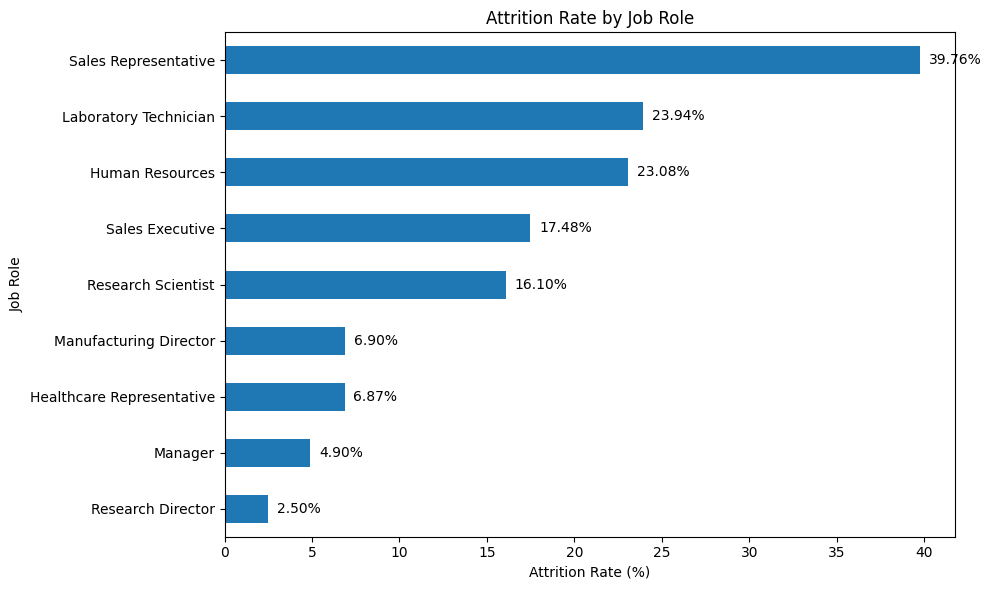

In [19]:
%matplotlib inline
plt.figure(figsize=(10, 6))

ax = jobrole_attrition["Yes"].sort_values().plot(kind="barh")

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

# Add percentage labels to each bar
for i, value in enumerate(jobrole_attrition["Yes"].sort_values()):
    ax.text(value + 0.5, i, f"{value:.2f}%", va="center")

plt.tight_layout()
plt.show()

In [15]:
from scipy.stats import chi2_contingency

# Create a frequency table
jobrole_contingency = pd.crosstab(
    df["JobRole"],
    df["Attrition"]
)

display(jobrole_contingency)

# Perform Chi-Square Test
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    jobrole_contingency
)

print("Chi-Square Statistic:", round(chi2, 2))
print("Degrees of Freedom:", degrees_of_freedom)
print("P-value:", p_value)

Attrition,No,Yes
JobRole,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


Chi-Square Statistic: 86.19
Degrees of Freedom: 8
P-value: 2.7524816380506567e-15


### Validation Details

The test produced the following results:

- **Chi-Square statistic:** 86.19
- **Degrees of freedom:** 8
- **p-value:** approximately 2.75 × 10^-15

Since the p-value is much smaller than the significance level of **0.05**, we **reject the null hypothesis (H0)**.

This provides statistically significant evidence that **job role and employee attrition are associated**.

Therefore, **H1 is supported**: employee attrition rates differ significantly across job roles.

A significance level of **α = 0.05** will be used.

### Final Conclusion 
The Chi-Square Test of Independence produced a p-value of approximately
**2.75 × 10⁻¹⁵**, which is much smaller than the significance level of
**0.05**.

Therefore, we **reject the null hypothesis (H₀)**.

The results provide statistically significant evidence of an association
between **job role and employee attrition**.

The exploratory analysis also showed substantial differences in attrition
rates across job roles, with Sales Representatives having the highest
attrition rate at **39.76%**, while Research Directors had the lowest at
**2.50%**.

Therefore, **H1 is supported**: employee attrition rates differ
significantly across job roles.

From a business perspective, HR may benefit from investigating the reasons
for higher attrition in specific job roles and developing targeted
retention strategies.